# 🎥 Video 04: 2D Molecular Visualization & Rendering
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 1 (Topic 05: Visualizing Molecules) & LEVEL 8 (Topic 47)
* **Target Audience:** Cheminformatics Engineers, Medicinal Chemists, AI Researchers

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Introduction: 2D Depiction Principles & Coordinate Generation
* **04:30 - 09:30** | Single Molecule Rendering: `MolToImage` & Image Sizing
* **09:30 - 15:00** | Grid Images: `MolsToGridImage` with Custom Legends and Styling
* **15:00 - 20:00** | Atom and Bond Highlighting with Custom RGB Color Schemes
* **20:00 - 25:00** | Publication-Ready Vector Graphics: `rdMolDraw2D` (SVG & Cairo)
* **25:00 - 28:00** | Visualizing Chemical Reactions
* **28:00 - 30:00** | Hands-On Challenge: Creating a High-Resolution Drug Infographic

---

### 🎯 Learning Objectives
1. Compute clear, aesthetic 2D coordinates with `rdDepictor.Compute2DCoords()`.
2. Generate professional multi-compound grid images with legends, formula, and property tags.
3. Highlight specific pharmacophore sub-structures, atoms, and bonds with custom RGB colors.
4. Export crisp, scalable SVG vector graphics suitable for papers and conference posters.
5. Depict chemical reactions with reactants, agents, and products.

In [1]:
# Step 0: Imports and Setup
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D, IPythonConsole
from IPython.display import SVG, display
import io

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (350, 250)

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Generating Aesthetic 2D Coordinates
Before rendering, 2D coordinates must be computed. RDKit uses the Riniker-Landrum 2D coordinate generation algorithm (`rdDepictor`) to produce aesthetically pleasing, standard organic chemistry layouts.

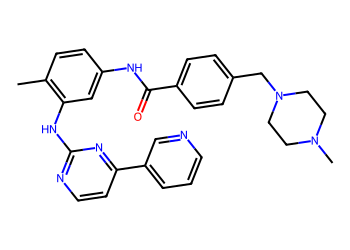

In [2]:
# Load Imatinib (Gleevec)
imatinib_smi = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"
imatinib = Chem.MolFromSmiles(imatinib_smi)

# Compute 2D coordinates explicitly
rdDepictor.Compute2DCoords(imatinib)

# Basic drawing
imatinib

## 2. Advanced Multi-Compound Grid Depictions (`MolsToGridImage`)
In virtual screening, you often need to review dozens of molecules side by side.
`MolsToGridImage` allows extensive customization:
* `molsPerRow`: Number of columns.
* `subImgSize`: Pixel size of each sub-image.
* `legends`: List of string labels for each compound.
* `useSVG`: True for crystal-clear vector graphics.

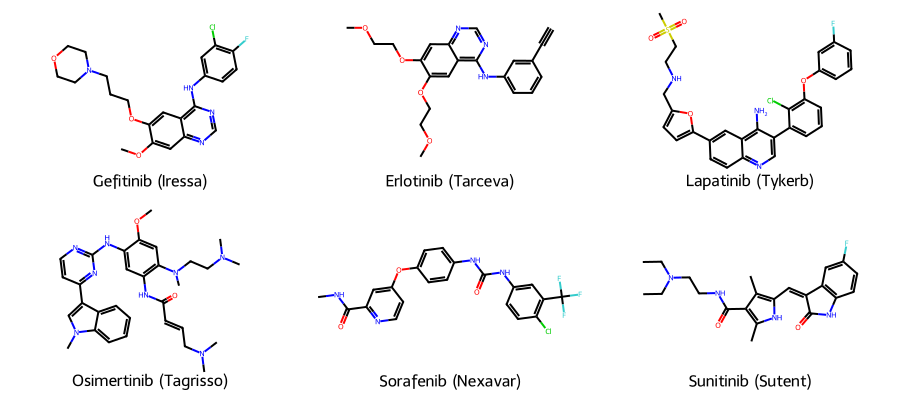

In [3]:
kinase_drugs = {
    "Gefitinib (Iressa)": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4",
    "Erlotinib (Tarceva)": "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1",
    "Lapatinib (Tykerb)": "CS(=O)(=O)CCNCc1ccc(o1)c2ccc3c(c2)c(c(cn3)c4cccc(c4Cl)Oc5cccc(c5)F)N",
    "Osimertinib (Tagrisso)": "CN(C)CC=CC(=O)Nc1cc(Nc2nccc(n2)c3cn(C)c4ccccc34)c(OC)cc1N(C)CCN(C)C",
    "Sorafenib (Nexavar)": "CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1",
    "Sunitinib (Sutent)": "CCN(CC)CCNC(=O)c1c(C)[nH]c(C=C2C(=O)Nc3ccc(F)cc23)c1C"
}

mols = [Chem.MolFromSmiles(smi) for smi in kinase_drugs.values()]
legends = list(kinase_drugs.keys())

# Render 2x3 grid
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 200), legends=legends, useSVG=True)

## 3. Highlighting Atoms and Bonds with Custom Colors
In drug discovery, you frequently want to highlight the **binding pharmacophore** or **functional group** in color.
We can pass `highlightAtoms`, `highlightBonds`, and custom RGB color dictionaries!

Matched atom indices: ((8, 7, 6, 5, 4, 3, 2, 20, 19, 18),)


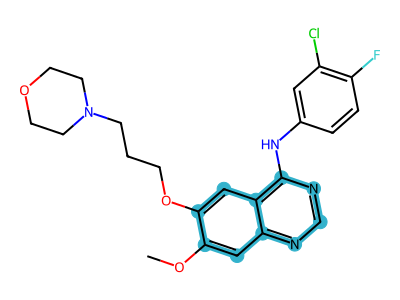

In [4]:
# Let's find the quinazoline core substructure in Gefitinib
gefitinib = mols[0]  # Gefitinib
quinazoline_pattern = Chem.MolFromSmarts("c1ncnc2ccccc12")

matches = gefitinib.GetSubstructMatches(quinazoline_pattern)
print(f"Matched atom indices: {matches}")

matched_atoms = list(matches[0])

# Highlight the matched atoms in soft teal
highlight_colors = {idx: (0.2, 0.7, 0.8) for idx in matched_atoms}

d2d = rdMolDraw2D.MolDraw2DSVG(400, 300)
d2d.DrawMolecule(gefitinib, highlightAtoms=matched_atoms, highlightAtomColors=highlight_colors)
d2d.FinishDrawing()
SVG(d2d.GetDrawingText())

## 4. Publication-Ready Vector Graphics (`rdMolDraw2D`)
For peer-reviewed journal papers, conference slides, or website banners, SVG vector format ensures infinitely scalable crisp graphics with custom styling (black background, atom numbers, thick bonds).

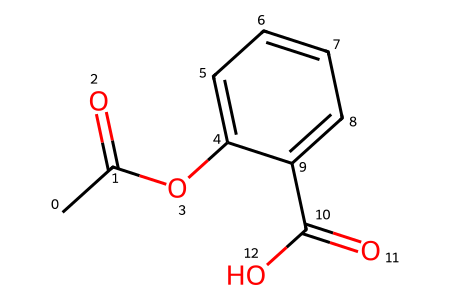

In [5]:
# Create a customized SVG depiction
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
rdDepictor.Compute2DCoords(aspirin)

drawer = rdMolDraw2D.MolDraw2DSVG(450, 300)
opts = drawer.drawOptions()

# Configure custom aesthetic options
opts.bondLineWidth = 3.0
opts.minFontSize = 12
opts.addAtomIndices = True  # Display atom numbers for reference

drawer.DrawMolecule(aspirin)
drawer.FinishDrawing()

# Display inline
SVG(drawer.GetDrawingText())

## 5. Visualizing Chemical Reactions
RDKit can also render chemical reactions directly in 2D with reactants, arrows, and products!

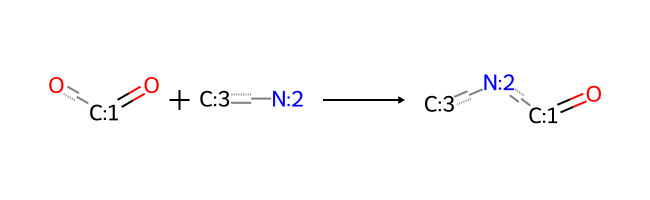

In [6]:
from rdkit.Chem import AllChem

# Amide coupling reaction: Carboxylic acid + Amine -> Amide
rxn_smarts = "[C:1](=O)[OH].[N:2][C:3]>>[C:1](=O)[N:2][C:3]"
rxn = AllChem.ReactionFromSmarts(rxn_smarts)

# Render reaction
d2d_rxn = rdMolDraw2D.MolDraw2DSVG(650, 200)
d2d_rxn.DrawReaction(rxn)
d2d_rxn.FinishDrawing()
SVG(d2d_rxn.GetDrawingText())

## 6. 🎯 Video Hands-On Challenge & Solution
### Problem:
Take **Lapatinib** and **Sorafenib**:
1. Identify all aromatic ring atoms in each molecule.
2. Render both side-by-side in an SVG grid.
3. Highlight all aromatic atoms in gold/orange `(1.0, 0.75, 0.1)`.
4. Label each molecule with its drug name and number of aromatic rings.

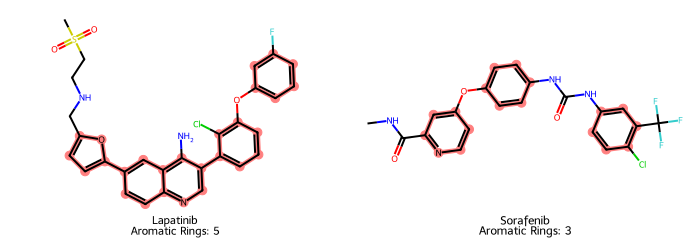

In [7]:
lapatinib = Chem.MolFromSmiles(kinase_drugs["Lapatinib (Tykerb)"])
sorafenib = Chem.MolFromSmiles(kinase_drugs["Sorafenib (Nexavar)"])

pair = [lapatinib, sorafenib]
pair_legends = []
pair_highlights = []

for idx, m in enumerate(pair):
    aromatic_atoms = [atom.GetIdx() for atom in m.GetAtoms() if atom.GetIsAromatic()]
    num_arom_rings = Chem.rdMolDescriptors.CalcNumAromaticRings(m)
    
    pair_highlights.append(aromatic_atoms)
    name = "Lapatinib" if idx == 0 else "Sorafenib"
    pair_legends.append(f"{name}\nAromatic Rings: {num_arom_rings}")

# Draw with highlights
Draw.MolsToGridImage(
    pair,
    legends=pair_legends,
    highlightAtomLists=pair_highlights,
    molsPerRow=2,
    subImgSize=(350, 250),
    useSVG=True
)

## 7. Summary & Key Takeaways
* `rdDepictor.Compute2DCoords` generates aesthetically pleasing 2D organic layout coordinates.
* `MolsToGridImage` with `useSVG=True` is the fastest, cleanest way to review chemical libraries.
* `rdMolDraw2D` provides granular programmatic control over line widths, colors, atom highlights, and background transparency for publication-quality figures.

**Next Up in Video 05:** **Physicochemical Properties & Molecular Descriptors** — calculating MW, LogP, TPSA, HBD, HBA, and building an automated descriptor extraction pipeline!